<a href="https://colab.research.google.com/github/dka0086/Analise-de-rede-de-grafos-Olist/blob/main/Olist_analise_grafos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Olist: rede de categorias por co-compra

Continuação do `Produtos_Olist.ipynb`. Este notebook substitui as células 7 a 10 do original (a bipartida clientes x produtos) e segue até a exportação para o Gephi.

**Pergunta:** quais categorias de produto fazem a ponte entre grupos de consumo no e-commerce brasileiro, e os hubs mais populares são também os que mais conectam grupos?

**Modelagem principal (rede A):**
- Bipartida: pedidos x categorias, só pedidos com 2 ou mais categorias distintas.
- Projeção: categorias ligadas quando aparecem no mesmo pedido. Não dirigida. Peso por contagem e por Jaccard.
- Fica de fora: pedidos de uma categoria só, pedidos cancelados ou indisponíveis, itens sem categoria, preço e frete.

**Comparação (rede B):** vendedores x categorias, projetada do mesmo jeito.

Cada bloco de análise termina com uma célula de texto para vocês escreverem a interpretação. É ali que o critério "Análise e interpretação" pontua.

## 0. Carga dos dados

In [ ]:
# Instalação (só a primeira vez no Colab)
!pip install -q nxviz plotly

In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms import bipartite
from scipy import sparse
from scipy.stats import spearmanr
import nxviz as nv
from nxviz import annotate
from matplotlib.lines import Line2D

DATA_DIR = Path(os.environ.get("OLIST_DATA", "data/"))
FIG_DIR = Path("figuras")
FIG_DIR.mkdir(exist_ok=True)

orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")
order_items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")
products = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")
product_category = pd.read_csv(
    DATA_DIR / "product_category_name_translation.csv", encoding="utf-8-sig"
)
print(orders.shape, order_items.shape, products.shape, product_category.shape)

(99441, 8) (112650, 7) (32951, 9) (71, 2)


## 1. Tabela de itens com categoria e passo zero

Decisões de modelagem (declarar no README): pedidos cancelados e indisponíveis saem; itens sem categoria saem; a categoria usa a tradução em inglês quando existe e o nome em português quando não existe.

In [ ]:
STATUS_FORA = ["canceled", "unavailable"]
col_en = product_category.columns[1]  # product_category_name_english

pedidos_validos = orders.loc[~orders["order_status"].isin(STATUS_FORA), "order_id"]

itens = (
    order_items[["order_id", "product_id", "seller_id"]]
    .merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
    .merge(product_category, on="product_category_name", how="left")
)
itens = itens[itens["order_id"].isin(pedidos_validos)].copy()
itens["categoria"] = itens[col_en].fillna(itens["product_category_name"])
itens = itens.dropna(subset=["categoria"])

print("itens:", len(itens), "| categorias:", itens["categoria"].nunique())

itens: 110512 | categorias: 73


In [ ]:
ncat = itens.groupby("order_id")["categoria"].nunique()
dist = ncat.value_counts().sort_index()
n_multi = int((ncat >= 2).sum())

print(f"Pedidos com categoria: {len(ncat):,}")
print(f"Pedidos com 2+ categorias: {n_multi:,} ({n_multi / len(ncat):.1%})")
display(dist.head(8).rename("pedidos").to_frame().rename_axis("categorias no pedido"))

if n_multi < 2000:
    print("Poucos pedidos com 2+ categorias: considere a rede B (vendedores) como principal.")

Pedidos com categoria: 96,824
Pedidos com 2+ categorias: 726 (0.7%)


,pedidos
categorias no pedido,
1,96098
2,711
3,15


Poucos pedidos com 2+ categorias: considere a rede B (vendedores) como principal.


**Interpretação (escrevam aqui):** que fração dos pedidos entra na rede? O que isso diz sobre o que a rede A representa e o que ela não representa?

## 2. Bipartida pedidos x categorias (semana 6)

In [ ]:
multi = ncat[ncat >= 2].index
pares = itens.loc[itens["order_id"].isin(multi), ["order_id", "categoria"]].drop_duplicates()

B = nx.Graph()
B.add_nodes_from(pares["order_id"].unique(), node_type="pedido")
B.add_nodes_from(pares["categoria"].unique(), node_type="categoria")
B.add_edges_from(pares.itertuples(index=False, name=None))

print("nós:", B.number_of_nodes(), "| arestas:", B.number_of_edges())
print("bipartida?", bipartite.is_bipartite(B))
invalidas = [(u, v) for u, v in B.edges() if B.nodes[u]["node_type"] == B.nodes[v]["node_type"]]
print("arestas inválidas:", len(invalidas))

nós: 787 | arestas: 1467
bipartida? True
arestas inválidas: 0


## 3. Projeção: contagem e Jaccard (semana 6)

A função abaixo faz a projeção pela matriz de incidência (BᵀB) e calcula os dois pesos:
- **contagem:** número de pedidos em que as duas categorias aparecem juntas;
- **Jaccard:** contagem dividida pelo número de pedidos que têm uma ou outra.

Ela é usada de novo mais adiante, para a análise do artefato de clique e para a rede de vendedores.

In [ ]:
def projetar(df, unidade, item):
    # Projeta a bipartida unidade x item numa rede de itens.
    # Retorna (G_contagem, G_jaccard), ambas com os mesmos nós e arestas.
    df = df[[unidade, item]].drop_duplicates()
    unidades = df[unidade].unique()
    itens_ = np.sort(df[item].unique())
    i = pd.Series(np.arange(len(unidades)), index=unidades).loc[df[unidade]].to_numpy()
    j = pd.Series(np.arange(len(itens_)), index=itens_).loc[df[item]].to_numpy()
    M = sparse.csr_matrix((np.ones(len(df)), (i, j)), shape=(len(unidades), len(itens_)))
    C = (M.T @ M).tocoo()
    tam = np.asarray(M.sum(axis=0)).ravel()  # unidades por item

    Gc, Gj = nx.Graph(), nx.Graph()
    for k, nome in enumerate(itens_):
        Gc.add_node(nome, n_unidades=int(tam[k]))
        Gj.add_node(nome, n_unidades=int(tam[k]))
    for a, b, w in zip(C.row, C.col, C.data):
        if a < b:
            Gc.add_edge(itens_[a], itens_[b], weight=float(w))
            Gj.add_edge(itens_[a], itens_[b], weight=float(w / (tam[a] + tam[b] - w)))
    return Gc, Gj


G_cont, G_jac = projetar(pares, "order_id", "categoria")
print("categorias:", G_cont.number_of_nodes(), "| arestas:", G_cont.number_of_edges())

categorias: 61 | arestas: 243


In [ ]:
# Conferência com o método da aula (bipartite.weighted_projected_graph)
G_ref = bipartite.weighted_projected_graph(B, list(G_cont.nodes))
iguais = all(G_ref[u][v]["weight"] == d["weight"] for u, v, d in G_cont.edges(data=True))
print("arestas:", G_cont.number_of_edges(), "vs", G_ref.number_of_edges(), "| pesos iguais:", iguais)

arestas: 243 vs 243 | pesos iguais: True


## 4. Estrutura básica (semana 2)

nós: 61 | arestas: 243
densidade: 0.133 | grau médio: 8.0
matriz de adjacência: (61, 61) | simétrica: True


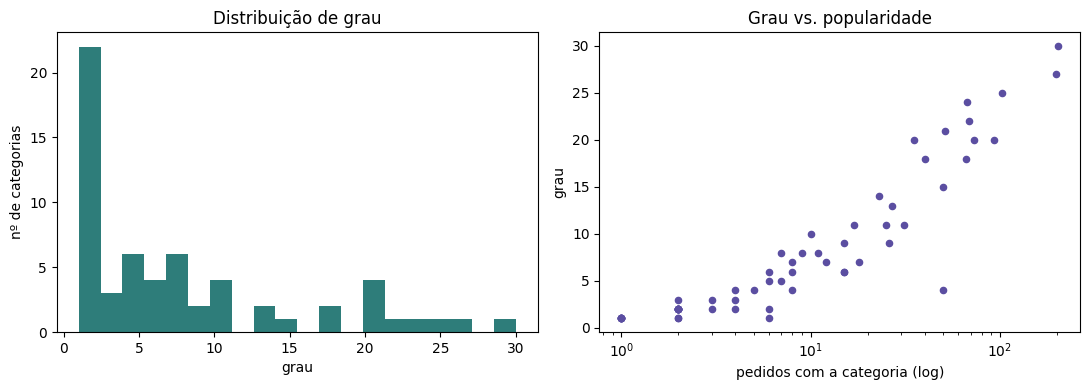

In [ ]:
graus = pd.Series(dict(G_jac.degree()))
pop = pd.Series(nx.get_node_attributes(G_jac, "n_unidades"))

print("nós:", G_jac.number_of_nodes(), "| arestas:", G_jac.number_of_edges())
print("densidade:", round(nx.density(G_jac), 3), "| grau médio:", round(graus.mean(), 1))
A = nx.to_numpy_array(G_cont)
print("matriz de adjacência:", A.shape, "| simétrica:", bool((A == A.T).all()))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(graus, bins=20, color="#2E7D7A")
ax[0].set(xlabel="grau", ylabel="nº de categorias", title="Distribuição de grau")
ax[1].scatter(pop, graus, s=20, color="#5B4EA1")
ax[1].set(xscale="log", xlabel="pedidos com a categoria (log)", ylabel="grau",
          title="Grau vs. popularidade")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_grau.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretação (escrevam aqui):** a distribuição de grau tem cauda longa? O grau acompanha a popularidade da categoria? Se sim, o que isso diz sobre "hub = popular"?

## 4.1 - Componentes, clustering e caminhos (semana 4)

A rede é não dirigida, então componentes fracamente e fortemente conectados coincidem. Digam isso no README.

In [ ]:
comps = sorted(nx.connected_components(G_jac), key=len, reverse=True)
gcc = G_jac.subgraph(comps[0]).copy()

print("componentes:", len(comps), "| isolados:", sum(1 for c in comps if len(c) == 1))
print(f"GCC: {gcc.number_of_nodes()} nós ({gcc.number_of_nodes() / G_jac.number_of_nodes():.0%})")
print("clustering médio:", round(nx.average_clustering(G_jac), 3),
      "| transitividade:", round(nx.transitivity(G_jac), 3))
if gcc.number_of_nodes() > 1:
    print("caminho médio (GCC):", round(nx.average_shortest_path_length(gcc), 2),
          "| diâmetro:", nx.diameter(gcc),
          "| eficiência global:", round(nx.global_efficiency(G_jac), 3))

componentes: 1 | isolados: 0
GCC: 61 nós (100%)
clustering médio: 0.45 | transitividade: 0.387
caminho médio (GCC): 2.28 | diâmetro: 5 | eficiência global: 0.502


## 4.2 - Hubs, pontes e centralidades (semana 4)

Na betweenness ponderada, o peso vira distância (1/peso), porque peso alto significa categorias próximas.

In [ ]:
for G in (G_cont, G_jac):
    for u, v, d in G.edges(data=True):
        d["dist"] = 1.0 / d["weight"]

bet_topo = nx.betweenness_centrality(G_jac)
bet_jac = nx.betweenness_centrality(G_jac, weight="dist")
bet_cont = nx.betweenness_centrality(G_cont, weight="dist")

eig = pd.Series(0.0, index=list(G_jac.nodes))
if gcc.number_of_nodes() > 2:
    eig.update(pd.Series(nx.eigenvector_centrality_numpy(gcc, weight="weight")))

cent = pd.DataFrame({
    "pedidos": pop,
    "grau": graus,
    "betw_topologica": pd.Series(bet_topo),
    "betw_jaccard": pd.Series(bet_jac),
    "betw_contagem": pd.Series(bet_cont),
    "eigenvector": eig,
})
cent["rank_grau"] = cent["grau"].rank(ascending=False, method="min").astype(int)
cent["rank_betw"] = cent["betw_jaccard"].rank(ascending=False, method="min").astype(int)

rho, _ = spearmanr(cent["grau"], cent["betw_jaccard"])
print("Spearman grau x betweenness (Jaccard):", round(rho, 3))
display(cent.sort_values("betw_jaccard", ascending=False).head(10).round(3))

Spearman grau x betweenness (Jaccard): 0.856


,pedidos,grau,betw_topologica,betw_jaccard,betw_contagem,eigenvector,rank_grau,rank_betw
baby,93,20,0.118,0.262,0.275,0.034,7,1
bed_bath_table,198,27,0.154,0.193,0.454,0.036,2,2
furniture_decor,203,30,0.167,0.164,0.481,0.033,1,3
cool_stuff,66,18,0.074,0.141,0.162,0.024,10,4
stationery,31,11,0.018,0.135,0.029,0.028,15,5
toys,50,15,0.030,0.131,0.071,0.023,12,6
health_beauty,69,22,0.065,0.129,0.133,0.024,5,7
computers_accessories,51,21,0.061,0.121,0.090,0.019,6,8
garden_tools,73,20,0.054,0.117,0.151,0.020,7,9
telephony,27,13,0.034,0.108,0.033,0.014,14,10


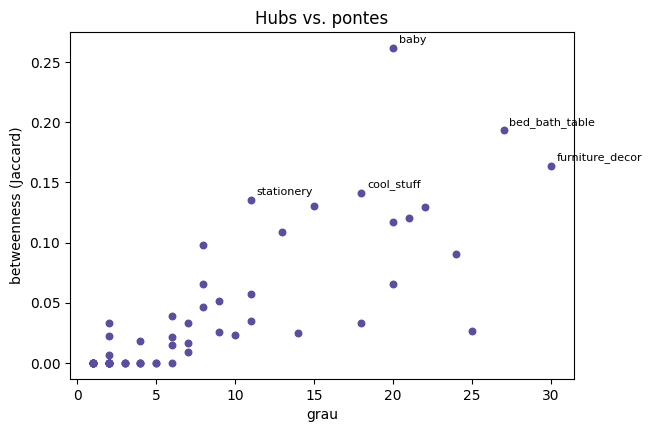

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(cent["grau"], cent["betw_jaccard"], s=22, color="#5B4EA1")
for nome, r in cent.nlargest(5, "betw_jaccard").iterrows():
    ax.annotate(nome, (r["grau"], r["betw_jaccard"]), fontsize=8, xytext=(4, 4),
                textcoords="offset points")
ax.set(xlabel="grau", ylabel="betweenness (Jaccard)", title="Hubs vs. pontes")
plt.savefig(FIG_DIR / "02_grau_vs_betweenness.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretação (escrevam aqui):** as categorias de maior grau são as de maior betweenness? Cite exemplos de categorias que são ponte sem serem as mais populares. O que a betweenness ponderada muda em relação à topológica?

### Qual é o nó mais importante?

In [ ]:
cent["closeness"] = pd.Series(nx.closeness_centrality(G_jac))
cols = ["grau", "closeness", "betw_jaccard", "eigenvector"]
cent["rank_medio"] = cent[cols].rank(ascending=False, method="min").mean(axis=1)
top = cent.sort_values("rank_medio").head(10)
display(top[["pedidos"] + cols + ["rank_medio"]].round(3))
print("nó mais importante (rank médio):", top.index[0])
print("líder em cada medida:", {c: cent[c].idxmax() for c in cols})

,pedidos,grau,closeness,betw_jaccard,eigenvector,rank_medio
bed_bath_table,198,27,0.632,0.193,0.036,2.50
furniture_decor,203,30,0.632,0.164,0.033,3.00
baby,93,20,0.583,0.262,0.034,5.25
health_beauty,69,22,0.606,0.129,0.024,6.50
cool_stuff,66,18,0.561,0.141,0.024,8.50
sports_leisure,67,24,0.600,0.090,0.020,9.00
garden_tools,73,20,0.566,0.117,0.020,9.75
computers_accessories,51,21,0.566,0.121,0.019,9.75
housewares,102,25,0.600,0.027,0.024,9.75
auto,35,20,0.588,0.066,0.021,10.00


nó mais importante (rank médio): bed_bath_table
líder em cada medida: {'grau': 'furniture_decor', 'closeness': 'bed_bath_table', 'betw_jaccard': 'baby', 'eigenvector': 'fashion_sport'}


## 7. Núcleo da rede (semana 5)

k máximo: 8
núcleo mais interno: ['auto', 'baby', 'bed_bath_table', 'computers_accessories', 'construction_tools_construction', 'cool_stuff', 'electronics', 'furniture_decor', 'garden_tools', 'health_beauty', 'housewares', 'luggage_accessories', 'perfumery', 'sports_leisure', 'stationery', 'telephony', 'toys', 'watches_gifts']

Categorias de grau alto (quartil superior) fora do núcleo mais interno:


,grau,core,onion,pedidos


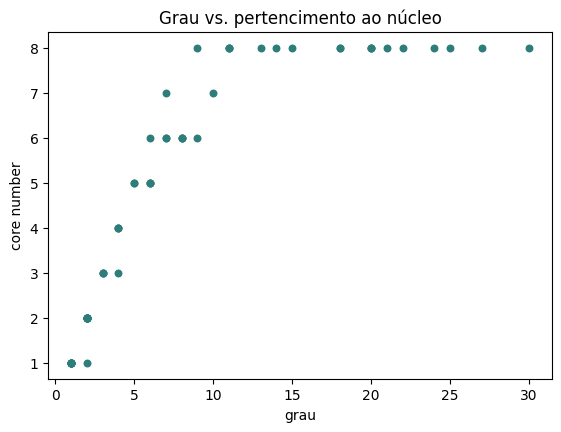

In [ ]:
cent["core"] = pd.Series(nx.core_number(G_jac))
cent["onion"] = pd.Series(nx.onion_layers(G_jac))
kmax = int(cent["core"].max())

print("k máximo:", kmax)
print("núcleo mais interno:", sorted(cent.index[cent["core"] == kmax]))

q75 = cent["grau"].quantile(0.75)
fora = cent[(cent["grau"] >= q75) & (cent["core"] < kmax)]
print("\nCategorias de grau alto (quartil superior) fora do núcleo mais interno:")
display(fora[["grau", "core", "onion", "pedidos"]].sort_values("grau", ascending=False))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(cent["grau"], cent["core"], s=22, color="#2E7D7A")
ax.set(xlabel="grau", ylabel="core number", title="Grau vs. pertencimento ao núcleo")
plt.savefig(FIG_DIR / "03_grau_vs_core.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretação (escrevam aqui):** quem está no núcleo mais interno? Há hubs fora dele, como nos exemplos da aula? O que o onion layers acrescenta ao k-core?

## 8. Artefato de clique (semana 6)

Um pedido com muitas categorias liga todas elas entre si e infla a densidade. A tabela mostra como a rede muda ao limitar o tamanho máximo do pedido.

,máx. categorias por pedido,pedidos,categorias,arestas,densidade,clustering,k máx
0,2,711,61,230,0.126,0.405,8
1,3,726,61,243,0.133,0.450,8
2,4,726,61,243,0.133,0.450,8
3,6,726,61,243,0.133,0.450,8
4,10,726,61,243,0.133,0.450,8


Arestas que só existem por causa de pedidos com mais de 4 categorias: 0 (0% do total)


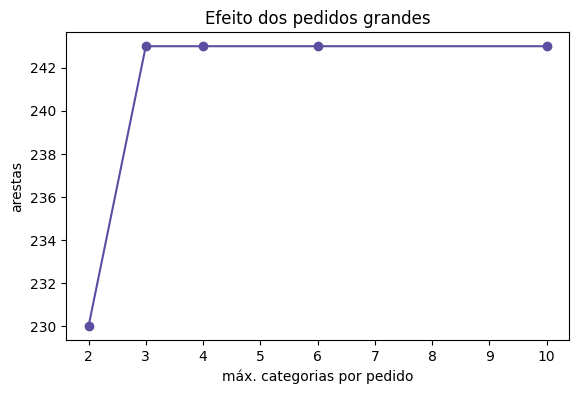

In [ ]:
tam_pedido = ncat[multi]
linhas = []
for L in [2, 3, 4, 6, 10, int(tam_pedido.max())]:
    ids = tam_pedido[tam_pedido <= L].index
    sub = pares[pares["order_id"].isin(ids)]
    if sub.empty:
        continue
    _, Gj = projetar(sub, "order_id", "categoria")
    linhas.append({
        "máx. categorias por pedido": L,
        "pedidos": sub["order_id"].nunique(),
        "categorias": Gj.number_of_nodes(),
        "arestas": Gj.number_of_edges(),
        "densidade": round(nx.density(Gj), 3),
        "clustering": round(nx.average_clustering(Gj), 3),
        "k máx": max(nx.core_number(Gj).values()),
    })
tab_clique = pd.DataFrame(linhas).drop_duplicates(subset="máx. categorias por pedido")
display(tab_clique)

L_REF = 4
ids_ref = tam_pedido[tam_pedido <= L_REF].index
_, G_ref4 = projetar(pares[pares["order_id"].isin(ids_ref)], "order_id", "categoria")
so_grandes = [e for e in G_jac.edges if not G_ref4.has_edge(*e)]
print(f"Arestas que só existem por causa de pedidos com mais de {L_REF} categorias:",
      len(so_grandes), f"({len(so_grandes) / G_jac.number_of_edges():.0%} do total)")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(tab_clique["máx. categorias por pedido"], tab_clique["arestas"], marker="o", color="#5B4EA1")
ax.set(xlabel="máx. categorias por pedido", ylabel="arestas", title="Efeito dos pedidos grandes")
plt.savefig(FIG_DIR / "04_artefato_clique.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretação (escrevam aqui):** quanto da rede depende de poucos pedidos grandes? Vocês limitariam o tamanho do pedido no modelo final? Justifiquem no README.

## 9. Backbone por limiar de peso (semana 6)

Mantém só as arestas com peso acima de um limiar. A tabela mostra o efeito de vários cortes, e o corte escolhido gera a rede final.

In [ ]:
def backbone(G, limiar):
    H = nx.Graph()
    H.add_nodes_from(G.nodes(data=True))
    H.add_edges_from((u, v, d) for u, v, d in G.edges(data=True) if d["weight"] >= limiar)
    return H


def resumo_rede(G):
    comps = list(nx.connected_components(G))
    return {
        "arestas": G.number_of_edges(),
        "densidade": round(nx.density(G), 3),
        "componentes": len(comps),
        "GCC": max((len(c) for c in comps), default=0),
        "clustering": round(nx.average_clustering(G), 3),
        "k máx": max(nx.core_number(G).values(), default=0),
    }


linhas = []
for nome, G in [("contagem", G_cont), ("jaccard", G_jac)]:
    pesos = np.array([d["weight"] for _, _, d in G.edges(data=True)])
    for q in [0, 0.25, 0.5, 0.75, 0.9]:
        lim = float(np.quantile(pesos, q))
        linhas.append({"peso": nome, "quantil": q, "limiar": round(lim, 4),
                       **resumo_rede(backbone(G, lim))})
tab_backbone = pd.DataFrame(linhas)
display(tab_backbone)

,peso,quantil,limiar,arestas,densidade,componentes,GCC,clustering,k máx
0,contagem,0.00,1.0000,243,0.133,1,61,0.450,8
1,contagem,0.25,1.0000,243,0.133,1,61,0.450,8
2,contagem,0.50,1.0000,243,0.133,1,61,0.450,8
3,contagem,0.75,2.0000,107,0.058,22,40,0.225,6
4,contagem,0.90,6.0000,27,0.015,43,19,0.069,2
5,jaccard,0.00,0.0038,243,0.133,1,61,0.450,8
6,jaccard,0.25,0.0106,182,0.099,5,57,0.294,6
7,jaccard,0.50,0.0192,122,0.067,8,54,0.153,5
8,jaccard,0.75,0.0361,61,0.033,19,41,0.064,2
9,jaccard,0.90,0.0711,25,0.014,37,5,0.038,2


In [ ]:
# Ajustem o quantil depois de olhar a tabela acima
Q_ESCOLHIDO = 0.5
pesos_j = np.array([d["weight"] for _, _, d in G_jac.edges(data=True)])
LIMIAR_JAC = float(np.quantile(pesos_j, Q_ESCOLHIDO))
G_bb = backbone(G_jac, LIMIAR_JAC)
print("limiar (Jaccard):", round(LIMIAR_JAC, 4))
print(resumo_rede(G_bb))

limiar (Jaccard): 0.0192
{'arestas': 122, 'densidade': 0.067, 'componentes': 8, 'GCC': 54, 'clustering': 0.153, 'k máx': 5}


**Interpretação (escrevam aqui):** o que muda no núcleo, no clustering e nas componentes quando o corte aumenta? Que categorias perdem todas as ligações? O corte escolhido faz sentido para a pergunta?

## 10. Comunidades (prévia) e exportação para o Gephi (semana 5)

A detecção de comunidades aqui é só uma prévia. A figura final e a modularidade vêm do Gephi, como nos vídeos da semana 5.

comunidades: 16 | modularidade: 0.546


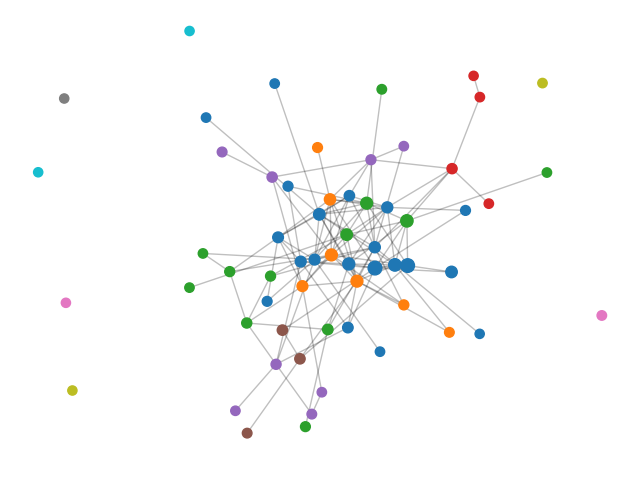

In [ ]:
comunidades = list(nx.community.greedy_modularity_communities(G_bb, weight="weight"))
comm = {n: k for k, c in enumerate(comunidades) for n in c}
mod = nx.community.modularity(G_bb, comunidades, weight="weight")
print("comunidades:", len(comunidades), "| modularidade:", round(mod, 3))

for n in G_bb.nodes:
    G_bb.nodes[n].update(
        grau=int(G_bb.degree(n)),
        betw_completa=float(cent.loc[n, "betw_jaccard"]),
        core_completa=int(cent.loc[n, "core"]),
        comunidade=int(comm[n]),
    )

nx.write_graphml(G_bb, FIG_DIR / "rede_categorias_backbone.graphml")
nx.write_graphml(G_jac, FIG_DIR / "rede_categorias_completa.graphml")

pos = nx.spring_layout(G_bb, seed=42, weight="weight")
tamanhos = [40 + 4 * G_bb.nodes[n]["n_unidades"] ** 0.5 for n in G_bb.nodes]
fig, ax = plt.subplots(figsize=(8, 6))
nx.draw_networkx_edges(G_bb, pos, alpha=0.25, ax=ax)
nx.draw_networkx_nodes(G_bb, pos, node_size=tamanhos,
                       node_color=[comm[n] for n in G_bb.nodes], cmap="tab10", ax=ax)
ax.set_axis_off()
plt.savefig(FIG_DIR / "05_rede_previa.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretação (escrevam aqui):** as comunidades correspondem a grupos de consumo reconhecíveis (por exemplo casa, moda, tecnologia)? Quais categorias ficam na fronteira entre grupos?

# Visulaização de Dados (Semana 4)

# 4.3 - Circus plot:

arestas entre comunidades: 61 de 122


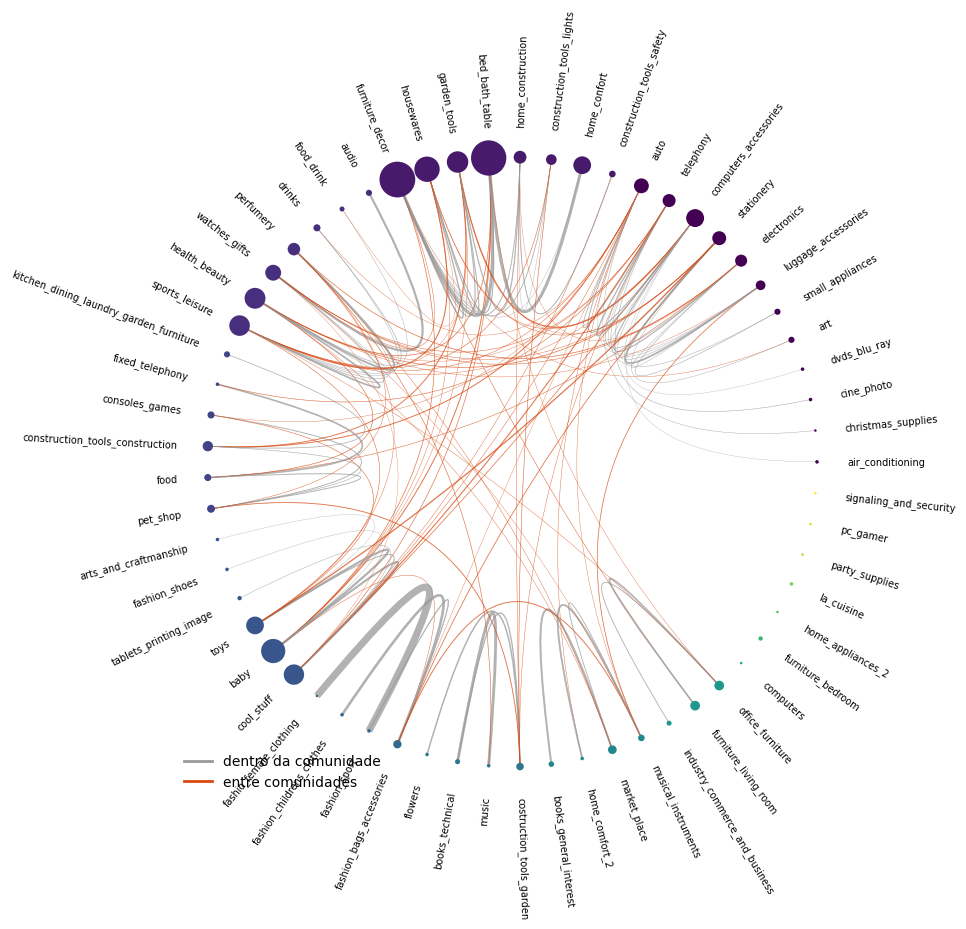

In [ ]:
from nxviz import annotate
from matplotlib.lines import Line2D

# tipo de cada aresta: dentro da mesma comunidade ou entre comunidades
for u, v, d in G_bb.edges(data=True):
    d["ligacao"] = ("dentro" if G_bb.nodes[u]["comunidade"] == G_bb.nodes[v]["comunidade"]
                    else "entre")

n_entre = sum(d["ligacao"] == "entre" for *_, d in G_bb.edges(data=True))
print(f"arestas entre comunidades: {n_entre} de {G_bb.number_of_edges()}")

COR_DENTRO, COR_ENTRE = "#9A9A9A", "#D9480F"

plt.figure(figsize=(9, 9))
nv.circos(
    G_bb, group_by="comunidade", sort_by="grau",
    node_color_by="comunidade", node_size_by="n_unidades",
    edge_lw_by="weight", edge_color_by="ligacao",
    node_enc_kwargs={"size_scale": 0.08},
    edge_enc_kwargs={"lw_scale": 10, "alpha_scale": 5},
    edge_palette={"dentro": COR_DENTRO, "entre": COR_ENTRE},
)
annotate.circos_labels(G_bb, group_by="comunidade", sort_by="grau",
                       layout="rotate", radius_offset=1.5, fontdict={"size": 7})
plt.legend(handles=[
    Line2D([0], [0], color=COR_DENTRO, lw=2, label="dentro da comunidade"),
    Line2D([0], [0], color=COR_ENTRE, lw=2, label="entre comunidades"),
], loc="lower left", frameon=False)
plt.savefig(FIG_DIR / "07_circos_projecao.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
w = pd.DataFrame(
    [("dentro" if G_bb.nodes[u]["comunidade"] == G_bb.nodes[v]["comunidade"] else "entre", d["weight"])
     for u, v, d in G_bb.edges(data=True)], columns=["ligacao", "peso"])
display(w.groupby("ligacao")["peso"].agg(["count", "mean", "median"]).round(4))

,count,mean,median
ligacao,,,
dentro,61,0.0778,0.0588
entre,61,0.0357,0.0303


# 4.3 - O que essa visualização sugere:

# 4.4 - Arc plot:

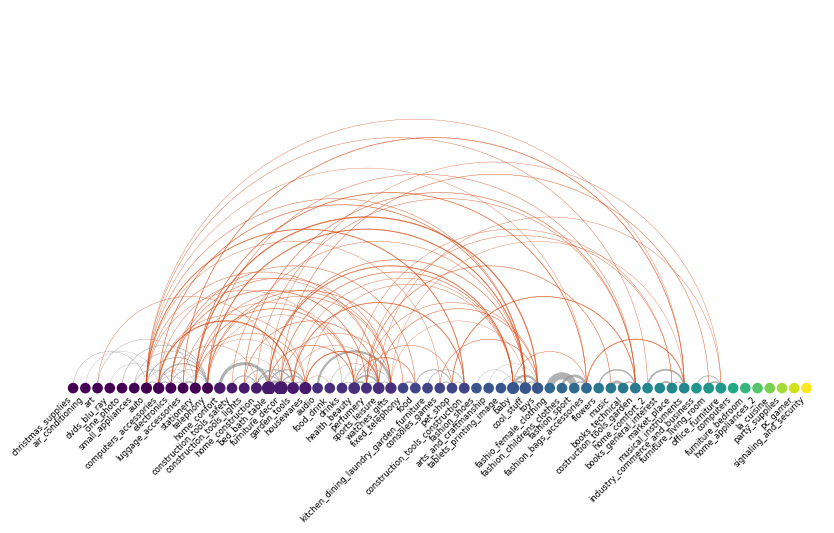

In [ ]:
# piso de tamanho e tipo de aresta (dentro/entre comunidades)
for n in G_bb.nodes:
    G_bb.nodes[n]["tam_arc"] = G_bb.nodes[n]["n_unidades"] + 300
for u, v, d in G_bb.edges(data=True):
    d["ligacao"] = ("dentro" if G_bb.nodes[u]["comunidade"] == G_bb.nodes[v]["comunidade"]
                    else "entre")

plt.figure(figsize=(14, 5))
nv.arc(
    G_bb, group_by="comunidade", sort_by="core_completa",
    node_color_by="comunidade", node_size_by="tam_arc",
    edge_color_by="ligacao", edge_lw_by="weight",
    node_enc_kwargs={"size_scale": 0.05},
    edge_enc_kwargs={"lw_scale": 10, "alpha_scale": 5},
    edge_palette={"dentro": "#9A9A9A", "entre": "#D9480F"},
)
annotate.arc_labels(G_bb, group_by="comunidade", sort_by="core_completa",
                    layout="standard", fontdict={"size": 6})
plt.savefig(FIG_DIR / "08_arc.png", dpi=150, bbox_inches="tight")
plt.show()

# 4.4 - O que essa visualização sugere:

# 4.5 - Matriz de Adjacencia

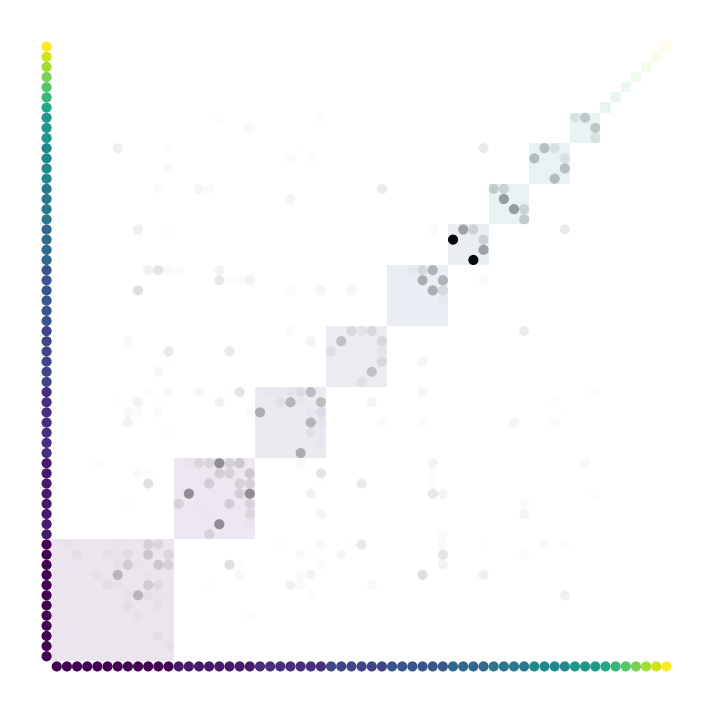

In [ ]:
plt.figure(figsize=(9, 9))
nv.matrix(
    G_bb, group_by="comunidade", sort_by="grau",
    node_color_by="comunidade", edge_alpha_by="weight",
)
annotate.matrix_group(G_bb, group_by="comunidade", offset=-8)
annotate.matrix_block(G_bb, group_by="comunidade", color_by="comunidade")
plt.savefig(FIG_DIR / "09_matriz.png", dpi=150, bbox_inches="tight")
plt.show()

# 4.5 - O que essa visualização sugere:

A matriz de adjacencia permite visaulizar os autovalores da rede, *Usar metodo de potencia e colocar em uma tabela*

In [ ]:
def metodo_potencia(A, tol=1e-10, max_iter=1000):
    x = np.ones(A.shape[0]) / np.sqrt(A.shape[0])
    hist, lam_ant = [], 0.0
    for k in range(1, max_iter + 1):
        y = A @ x
        x = y / np.linalg.norm(y)
        lam = float(x @ A @ x)                 # quociente de Rayleigh
        hist.append((k, lam, abs(lam - lam_ant)))
        if abs(lam - lam_ant) < tol:
            break
        lam_ant = lam
    return lam, x, pd.DataFrame(hist, columns=["iteração", "λ estimado", "|Δλ|"])

nodos = list(gcc.nodes)
mats = {"binária": nx.to_numpy_array(gcc, nodelist=nodos, weight=None),
        "Jaccard": nx.to_numpy_array(gcc, nodelist=nodos, weight="weight")}

linhas, hists, vetores = [], {}, {}
for nome, A_ in mats.items():
    lam, v, h = metodo_potencia(A_)
    vals = np.sort(np.linalg.eigvalsh(A_))[::-1]
    linhas.append({"matriz": nome, "λ1 (potência)": round(lam, 6), "λ1 (numpy)": round(vals[0], 6),
                   "λ2 (numpy)": round(vals[1], 6), "razão λ2/λ1": round(vals[1] / vals[0], 3),
                   "iterações": len(h)})
    hists[nome], vetores[nome] = h, pd.Series(v, index=nodos)

display(pd.DataFrame(linhas))
display(hists["Jaccard"].head(6))                       # convergência
rho, _ = spearmanr(vetores["Jaccard"], cent.loc[nodos, "eigenvector"])
print("Spearman (potência x eigenvector_centrality):", round(rho, 4))
print("top 5 pelo autovetor:", list(vetores["Jaccard"].nlargest(5).index))

,matriz,λ1 (potência),λ1 (numpy),λ2 (numpy),razão λ2/λ1,iterações
0,binária,14.537540,14.537540,4.197997,0.289,13
1,Jaccard,0.508361,0.508532,0.472306,0.929,1000


,iteração,λ estimado,|Δλ|
0,1,0.460072,0.460072
1,2,0.474338,0.014266
2,3,0.478455,0.004117
3,4,0.480373,0.001918
4,5,0.481699,0.001326
5,6,0.482881,0.001181


Spearman (potência x eigenvector_centrality): 0.9998
top 5 pelo autovetor: ['fashio_female_clothing', 'fashion_sport', 'fashion_bags_accessories', 'fashion_childrens_clothes', 'bed_bath_table']


# 4.6 - Análise sobre a geometria da rede:

In [ ]:
exc = pd.Series(nx.eccentricity(gcc))
centro, periferia = nx.center(gcc), nx.periphery(gcc)
print("raio:", nx.radius(gcc), "| diâmetro:", nx.diameter(gcc))
print("centro:", sorted(centro))
print("periferia (geométrica):", sorted(periferia))

shell = pd.Series(nx.core_number(G_jac))
print(f"periferia estrutural (k-shell {shell.min()}):", sorted(shell.index[shell == shell.min()]))

cent["excentricidade"] = exc
display(cent.loc[centro + periferia, ["pedidos", "grau", "excentricidade"]].round(3))

raio: 3 | diâmetro: 5
centro: ['auto', 'baby', 'bed_bath_table', 'fashion_bags_accessories', 'health_beauty', 'musical_instruments', 'stationery']
periferia (geométrica): ['air_conditioning', 'arts_and_craftmanship', 'audio', 'cine_photo', 'computers', 'dvds_blu_ray', 'fashio_female_clothing', 'fixed_telephony', 'flowers', 'food_drink', 'home_construction', 'industry_commerce_and_business', 'music', 'pc_gamer', 'tablets_printing_image']
periferia estrutural (k-shell 1): ['audio', 'christmas_supplies', 'computers', 'fashio_female_clothing', 'fashion_childrens_clothes', 'fashion_shoes', 'fashion_sport', 'home_appliances_2', 'party_supplies', 'pc_gamer', 'signaling_and_security']


,pedidos,grau,excentricidade
auto,35,20,3
baby,93,20,3
bed_bath_table,198,27,3
fashion_bags_accessories,11,8,3
health_beauty,69,22,3
musical_instruments,7,8,3
stationery,31,11,3
air_conditioning,2,2,5
arts_and_craftmanship,2,2,5
audio,6,1,5


## 11. Rede B: vendedores x categorias (comparação de modelagem)

Aqui duas categorias se ligam quando o mesmo vendedor atua nas duas. Isso mede "quem vende junto", não "quem compra junto". Uma comparação das duas redes mostra o efeito da escolha de modelagem.

In [ ]:
pares_v = itens[["seller_id", "categoria"]].drop_duplicates()
n_cat_v = pares_v.groupby("seller_id")["categoria"].nunique()
pares_v = pares_v[pares_v["seller_id"].isin(n_cat_v[n_cat_v >= 2].index)]
print("vendedores com 2+ categorias:", pares_v["seller_id"].nunique())

GB_cont, GB_jac = projetar(pares_v, "seller_id", "categoria")
print("rede B -> nós:", GB_jac.number_of_nodes(), "| arestas:", GB_jac.number_of_edges(),
      "| densidade:", round(nx.density(GB_jac), 3))

ea = {frozenset(e) for e in G_jac.edges}
eb = {frozenset(e) for e in GB_jac.edges}
print("arestas A:", len(ea), "| B:", len(eb), "| em comum:", len(ea & eb),
      "| Jaccard entre conjuntos de arestas:", round(len(ea & eb) / len(ea | eb), 3))

comuns = [tuple(e) for e in ea & eb]
if len(comuns) > 2:
    rho_w, _ = spearmanr([G_jac[u][v]["weight"] for u, v in comuns],
                         [GB_jac[u][v]["weight"] for u, v in comuns])
    print("Spearman dos pesos nas arestas em comum:", round(rho_w, 3))

cmp = pd.DataFrame({"grau_A": dict(G_jac.degree()), "grau_B": dict(GB_jac.degree())}).fillna(0)
if cmp["grau_A"].nunique() > 1 and cmp["grau_B"].nunique() > 1:
    rho_g, _ = spearmanr(cmp["grau_A"], cmp["grau_B"])
    print("Spearman dos graus A x B:", round(rho_g, 3))
else:
    print("Graus constantes em uma das redes (rede completa): correlação não definida.")

vendedores com 2+ categorias: 1297
rede B -> nós: 73 | arestas: 1373 | densidade: 0.522
arestas A: 243 | B: 1373 | em comum: 236 | Jaccard entre conjuntos de arestas: 0.171
Spearman dos pesos nas arestas em comum: 0.288
Spearman dos graus A x B: 0.758


**Interpretação (escrevam aqui):** as duas redes contam a mesma história? Em que categorias elas divergem e por quê (quem compra junto vs. quem vende junto)?

## 12. Tabela para o README

Preencham "onde aparece" com o número real das células depois de organizar o notebook final.

| conceito | semana | onde aparece | para que serviu |
|---|---|---|---|
| grafo bipartido (pedidos x categorias) | 6 | seção 2 | modelar a co-compra |
| projeção unipartida, BᵀB | 6 | seção 3 | rede de categorias |
| peso por contagem vs. Jaccard | 6 | seção 3 | reduzir o viés de popularidade |
| artefato de clique | 6 | seção 8 | efeito de pedidos grandes |
| backbone por limiar de peso | 6 | seção 9 | filtrar arestas fracas |
| densidade, grau e distribuição de grau | 2 | seção 4 | forma geral da rede |
| matriz de adjacência | 2 | seção 4 | representação da rede |
| componentes e GCC (WCC = SCC, pois é não dirigida) | 4 | seção 5 | fragmentação |
| clustering e transitividade | 4 | seção 5 | coesão local |
| caminho médio, diâmetro, eficiência | 4 | seção 5 | proximidade global |
| betweenness (topológica e ponderada) | 4 | seção 6 | categorias-ponte |
| eigenvector | 4 | seção 6 | importância por vizinhos |
| k-core, core number, onion layers | 5 | seção 7 | núcleo da rede |
| Gephi (comunidades, layout, figura final) | 5 | figuras/ | grupos e visualização |